In [1]:
import joblib
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit,StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from utils import *
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import wandb
import pandas as pd
from utils import *

from pathlib import Path

In [2]:
rf_model = joblib.load("../../artifacts/Random_Forest.joblib")
rf_features = joblib.load("../../artifacts/rf_features.joblib")

xgb_model_rf = joblib.load("../../artifacts/xgb_model_in_ensemble.joblib")

lgbm_model = joblib.load("../../artifacts/lgbm_pipeline.joblib")   
lgbm_features = joblib.load("../../artifacts/lgbm_features.joblib")

xgb_model = joblib.load("../../artifacts/xgb_model.joblib")
xgb_features = joblib.load("../../artifacts/xgb_features.joblib")

lr_model = joblib.load("../../artifacts/lr_model.joblib")
lr_features = joblib.load("../../artifacts/lr_features.joblib")

In [3]:
import json

def load_config(path):
    with open(path, "r") as f:
        return json.load(f)
    
config_lgbm_rf = load_config("../../artifacts/ensemble_lgbm_rf_config.json")
config_rf_xgb = load_config("../../artifacts/ensemble_rf_xgb_config.json")
config_xgb_lgbm = load_config("../../artifacts/ensemble_xgb_lgbm_config.json")    
    
w_rf = config_lgbm_rf["weights"]["rf"]
w_lgbm = config_lgbm_rf["weights"]["lgbm"]
threshold_lgbm_rf = config_lgbm_rf["threshold"]

w_xgb = config_rf_xgb["weights"]["rf"]
w_rf_in_xgb = config_rf_xgb["weights"]["xgb"]
threshold_rf_xgb = config_rf_xgb["threshold"]

w_xgb_in_lgbm = config_xgb_lgbm["weights"]["xgb"]
w_lgbm_in_xgb = config_xgb_lgbm["weights"]["lgbm"]
threshold_xgb_lgbm = config_xgb_lgbm["threshold"]

In [4]:
df = pd.read_csv('../../data/creditcard.csv')

df = create_features(df)
df['_log_amount_raw'] = df['_log_amount']
scaler = StandardScaler()
df[['_log_amount']] = scaler.fit_transform(df[['_log_amount']])
df['hour_sin'] = np.sin(2 * np.pi * df['Hour_from_start_mod24']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['Hour_from_start_mod24']/24)
df['time_diff'] = df['Time'].diff().fillna(0)
threshold = df['Amount'].quantile(0.95)  
df['is_high_amount'] = (df['Amount'] > threshold).astype(int)
df['is_rapid_transaction'] = (df['time_diff'] < 60).astype(int)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,_log_amount,Hour_from_start_mod24,is_night_proxy,is_business_hours_proxy,_log_amount_raw,hour_sin,hour_cos,time_diff,is_high_amount,is_rapid_transaction
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,1.123062,0,1,0,5.014760,0.0,1.0,0.0,0,1
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-1.115298,0,1,0,1.305626,0.0,1.0,0.0,0,1
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,1.680981,0,1,0,5.939276,0.0,1.0,1.0,1,1
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,1.008128,0,1,0,4.824306,0.0,1.0,0.0,0,1
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.669117,0,1,0,4.262539,0.0,1.0,1.0,0,1


In [5]:
lgbm_features = ['_log_amount_raw' if c == '_log_amount' else c for c in lgbm_features]
lr_features = ['_log_amount_raw' if c == '_log_amount' else c for c in lr_features]

In [6]:
all_features = sorted(set(rf_features) | set(lgbm_features))
print("Total union features:", len(all_features))

Total union features: 39


In [7]:
X_train, y_train, X_val, y_val, X_test, y_test = split_data(df, all_features, 'Class')

X_train: (181584, 39) y_train: (181584,)
X_val: (45396, 39) y_val: (45396,)
X_test: (56746, 39) y_test: (56746,)
Fraud rate in train: 0.001910961318177813
Fraud rate in test: 0.0013040566735981391


In [8]:
#LR chung data với LGBM
#XGB chung data với RF, XGB_in_RF
X_test_rf = X_test[rf_features]

X_test_lgbm = X_test[lgbm_features]
X_test_lr = X_test[lr_features]

In [9]:
rf_test_proba = rf_model.predict_proba(X_test_rf)[:, 1]
xgb_test_proba_in_rf = xgb_model_rf.predict_proba(X_test_rf)[:, 1]

lgbm_test_proba = lgbm_model.predict_proba(X_test_lgbm)[:, 1]

xgb_test_proba = xgb_model.predict_proba(X_test_rf)[:, 1]


[LightGBM] [Warning] Unknown parameter: n_job
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0


In [17]:
ensemble_lgbm_rf = w_rf * rf_test_proba + w_lgbm * lgbm_test_proba
ensemble_rf_xgb = w_xgb* rf_test_proba +  w_rf_in_xgb  * xgb_test_proba_in_rf
ensemble_xgb_lgbm = w_xgb_in_lgbm * xgb_test_proba + w_lgbm_in_xgb * lgbm_test_proba

In [19]:
preds_test = { 
    "Random Forest": rf_test_proba,
    "LGBM": lgbm_test_proba,
    "XGB": xgb_test_proba,
    "Ensemble LGBM + RF": ensemble_lgbm_rf,
    "Ensemble RF + XGB": ensemble_rf_xgb,
    "Ensemble XGB + LGBM": ensemble_xgb_lgbm
}

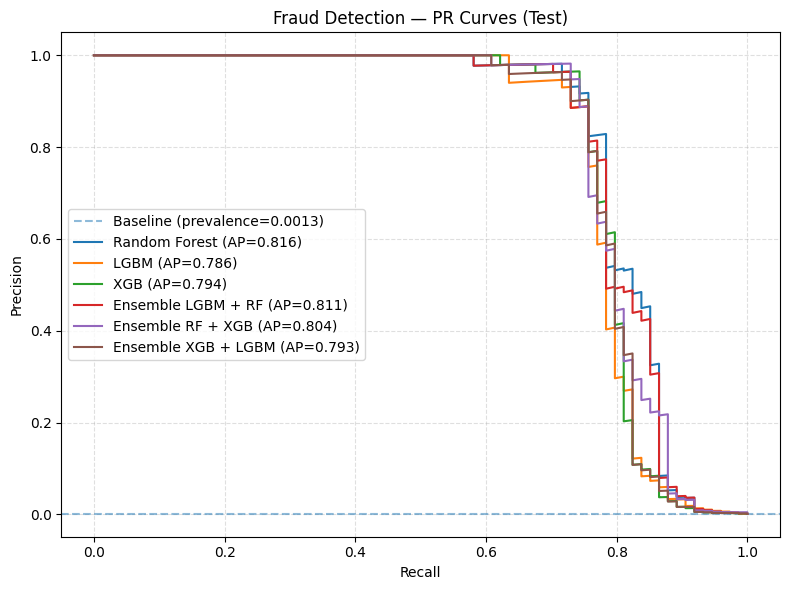

In [20]:
plot_pr_overlay(y_test, preds_test, title="Fraud Detection — PR Curves (Test)")

In [21]:
reliab_models = {
    "Random Forest": rf_test_proba,
    "LGBM": lgbm_test_proba,
    "XGB": xgb_test_proba,
    "Ensemble LGBM + RF": ensemble_lgbm_rf,
    "Ensemble RF + XGB": ensemble_rf_xgb,
    "Ensemble XGB + LGBM": ensemble_xgb_lgbm
}

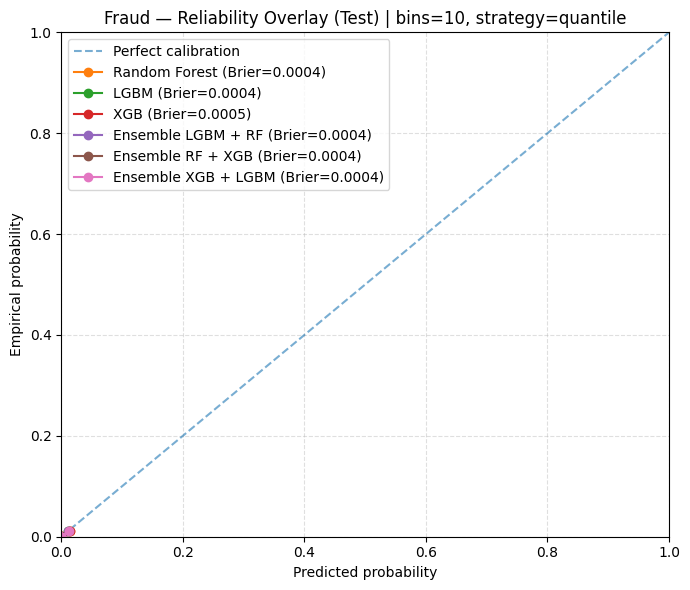

In [22]:
reliability_overlay(y_test, reliab_models, bins=10, strategy="quantile",
                    title="Fraud — Reliability Overlay (Test)")

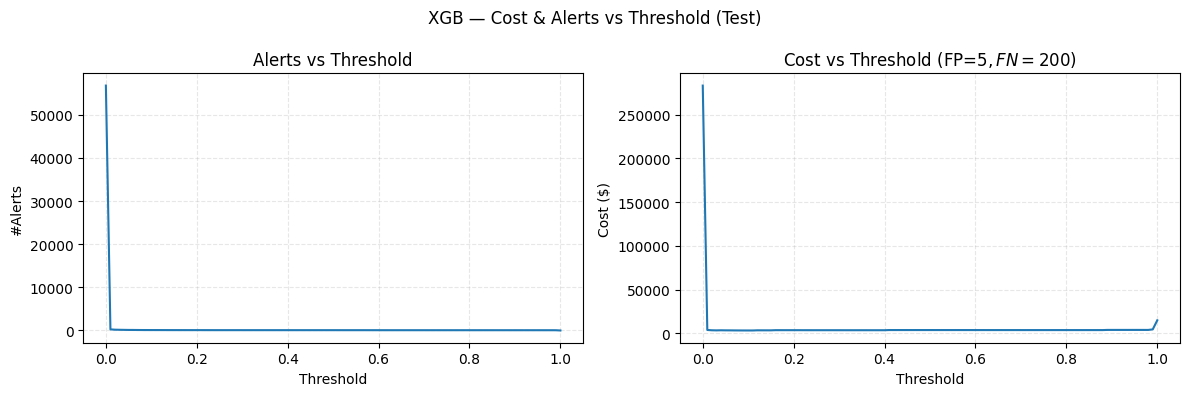

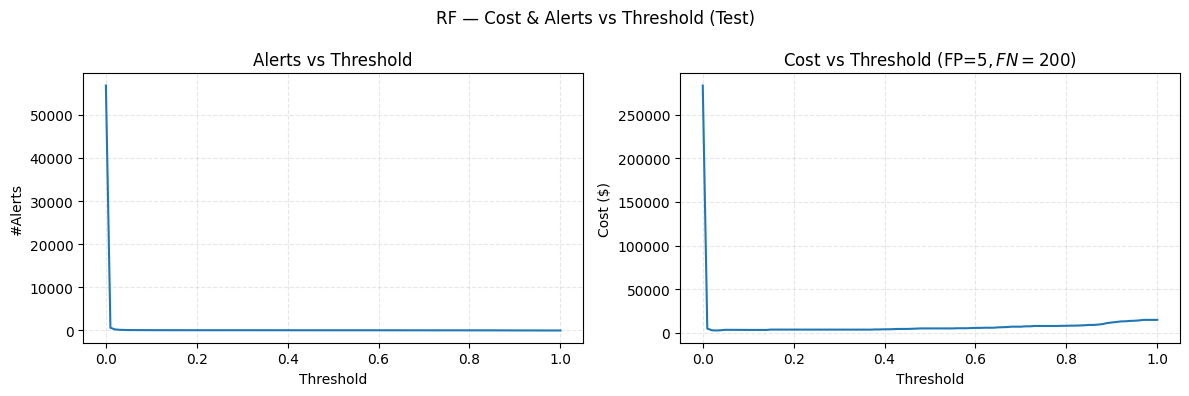

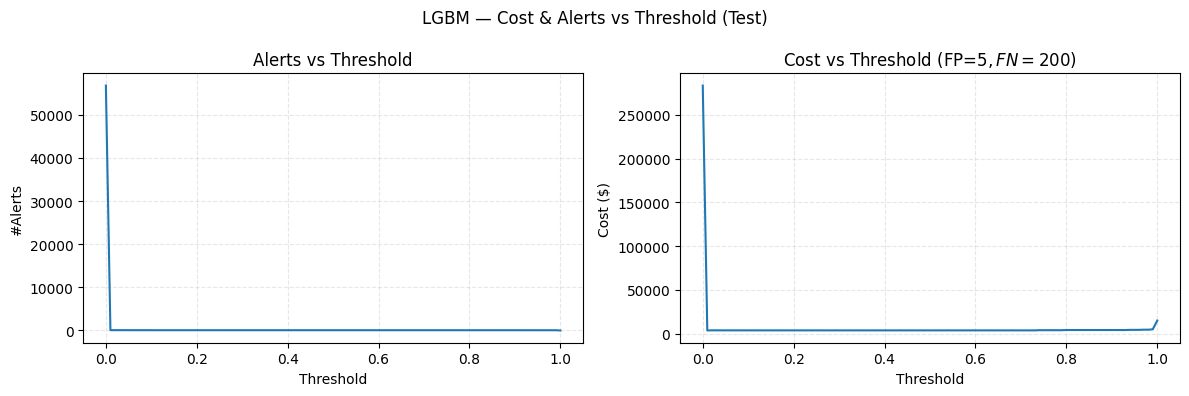

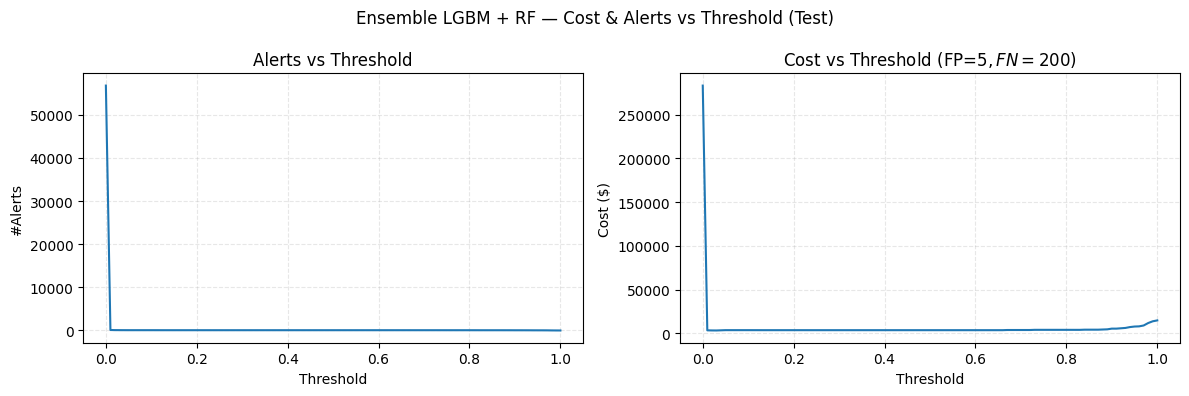

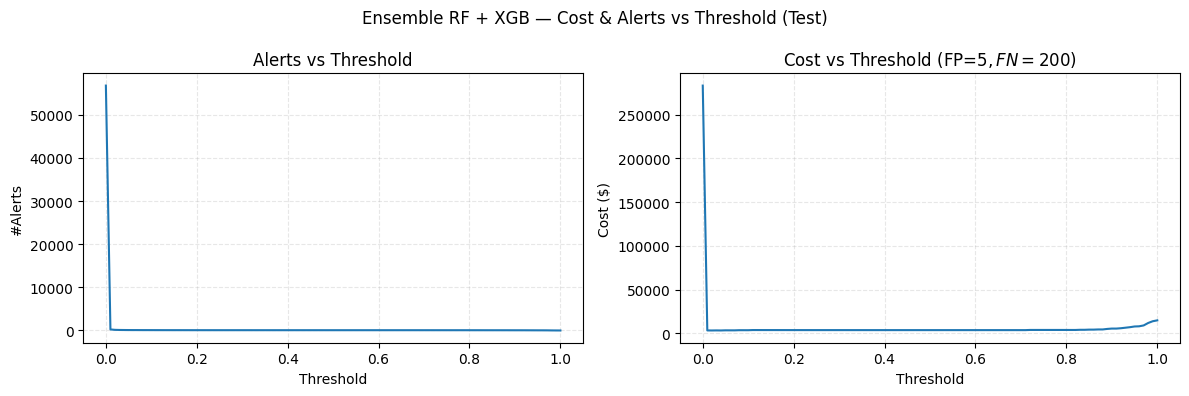

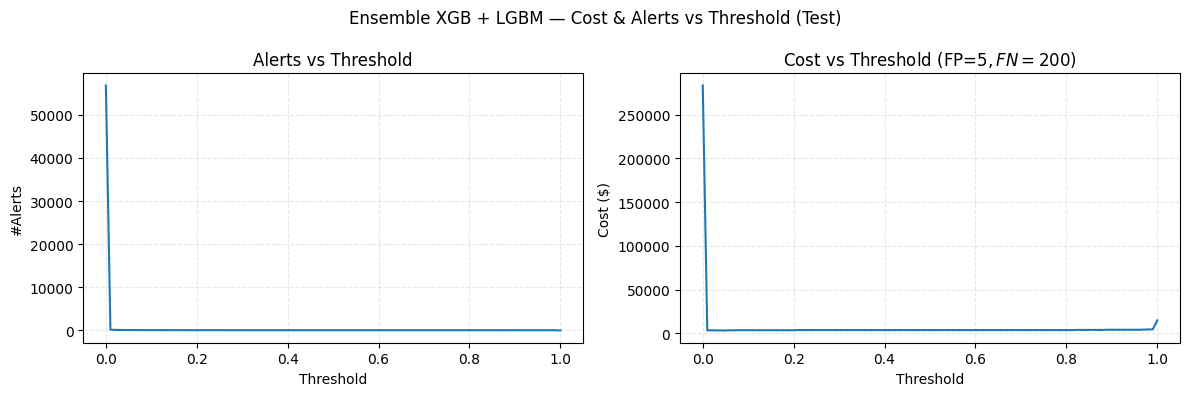

In [23]:
df_xgb_sweep = plot_cost_and_alerts(y_test, xgb_test_proba, cost_fp=COST_FP, cost_fn=COST_FN,
                                      title="XGB — Cost & Alerts vs Threshold (Test)")
df_rf_sweep = plot_cost_and_alerts(y_test, rf_test_proba, cost_fp=COST_FP, cost_fn=COST_FN,
                                      title="RF — Cost & Alerts vs Threshold (Test)")
df_lgbm_sweep = plot_cost_and_alerts(y_test, lgbm_test_proba, cost_fp=COST_FP, cost_fn=COST_FN,
                                      title="LGBM — Cost & Alerts vs Threshold (Test)")
df_ensemble_lgbm_rf_sweep = plot_cost_and_alerts(y_test, ensemble_lgbm_rf, cost_fp=COST_FP, cost_fn=COST_FN,
                                      title="Ensemble LGBM + RF — Cost & Alerts vs Threshold (Test)")
df_ensemble_rf_xgb_sweep = plot_cost_and_alerts(y_test, ensemble_rf_xgb, cost_fp=COST_FP, cost_fn=COST_FN,
                                      title="Ensemble RF + XGB — Cost & Alerts vs Threshold (Test)")
df_ensemble_xgb_lgbm_sweep = plot_cost_and_alerts(y_test, ensemble_xgb_lgbm, cost_fp=COST_FP, cost_fn=COST_FN,
                                      title="Ensemble XGB + LGBM — Cost & Alerts vs Threshold (Test)")

In [24]:
def summarise_model(name, y_true, y_prob, best_thresholds):
    ap = average_precision_score(y_true, y_prob)
    roc = roc_auc_score(y_true, y_prob)
    brier = brier_score_loss(y_true, y_prob)
    ece = adaptive_ece(y_true.values, y_prob, n_bins=15)
    cost_p90 = realized_cost(y_true, y_prob, best_thresholds, COST_FP, COST_FN)
    cost_min = realized_cost(y_true, y_prob, best_thresholds, COST_FP, COST_FN)
    ap_lo, ap_hi = bootstrap_ci(average_precision_score, y_true.values, y_prob)
    return {
        "Model": name, "AP(Test)": ap, "AP 95% CI": f"[{ap_lo:.3f}, {ap_hi:.3f}]",
        "ROC-AUC(Test)": roc, "Brier(Test)": brier, "ECE(15)": ece,
        "Best_Thresholds": best_thresholds,
        "Cost@Test@P90": cost_p90, "Cost@Test@MinCost": cost_min,
    }

In [25]:
summary_df = pd.DataFrame([
    summarise_model("LGBM + RF",  y_test, ensemble_lgbm_rf,  threshold_lgbm_rf),
    summarise_model("XGB + RF", y_test, ensemble_rf_xgb, threshold_rf_xgb),
    summarise_model("XGB + LGBM", y_test, ensemble_xgb_lgbm, threshold_xgb_lgbm)
]).sort_values("AP(Test)", ascending=False)

In [26]:
display(summary_df.round(4))

,Model,AP(Test),AP 95% CI,ROC-AUC(Test),Brier(Test),ECE(15),Best_Thresholds,Cost@Test@P90,Cost@Test@MinCost
0,LGBM + RF,0.8111,"[0.720, 0.885]",0.9784,0.0004,0.0001,0.25,3635.0,3635.0
1,XGB + RF,0.8040,"[0.725, 0.882]",0.9808,0.0004,0.0002,0.70,3635.0,3635.0
2,XGB + LGBM,0.7933,"[0.695, 0.872]",0.9657,0.0004,0.0002,0.50,3635.0,3635.0


### Alerts and Fraud caught per 100k

In [27]:
def summarize_ops(y_true, y_prob, thr, name, cost_fp=COST_FP, cost_fn=COST_FN):
    yhat = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yhat, labels=[0,1]).ravel()
    N = len(y_true)
    alerts = tp + fp
    cost = fp*cost_fp + fn*cost_fn
    savings = tp*cost_fn - fp*cost_fp  

    return {
        "Model": name,
        "Threshold": float(thr),
        "TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn),
        "Precision": precision_score(y_true, yhat, zero_division=0),
        "Recall": recall_score(y_true, yhat),
        "F1": f1_score(y_true, yhat, zero_division=0),
        "Alerts": int(alerts),
        "Alerts/100k":  (alerts / N) * 100000,
        "FraudCaught/100k": (tp / N) * 100000,
        "Cost($)": cost,
        "Cost/100k($)": (cost / N) * 100000,
        "NetSavings($)": savings
    }


In [28]:
ops_rows = []
ops_rows.append(summarize_ops(y_test, ensemble_lgbm_rf,  threshold_lgbm_rf,  "LGBM + RF"))
ops_rows.append(summarize_ops(y_test, ensemble_rf_xgb, threshold_rf_xgb,"XGB + RF"))
ops_rows.append(summarize_ops(y_test, ensemble_xgb_lgbm, threshold_xgb_lgbm,"XGB + LGBM"))
ops_df = pd.DataFrame(ops_rows)

In [29]:
prevalence = y_test.mean()
ops_df["Alerts%"] = (ops_df["Alerts/100k"] / 100000) * 100
ops_df["PrecisionLift(x)"] = ops_df["Precision"] / max(1e-9, prevalence)

cols_order = [
    "Model","Threshold",
    "TP","FP","FN","TN",
    "Precision","Recall","F1",
    "Alerts","Alerts%","Alerts/100k","FraudCaught/100k",
    "Cost($)","Cost/100k($)","NetSavings($)","PrecisionLift(x)"
]
ops_df = ops_df[cols_order].round(4)

In [30]:
display(ops_df)

,Model,Threshold,TP,FP,FN,TN,Precision,Recall,F1,Alerts,Alerts%,Alerts/100k,FraudCaught/100k,Cost($),Cost/100k($),NetSavings($),PrecisionLift(x)
0,LGBM + RF,0.25,56,7,18,56665,0.8889,0.7568,0.8175,63,0.111,111.021,98.6854,3635.0,6405.7378,11165.0,681.6336
1,XGB + RF,0.70,56,7,18,56665,0.8889,0.7568,0.8175,63,0.111,111.021,98.6854,3635.0,6405.7378,11165.0,681.6336
2,XGB + LGBM,0.50,56,7,18,56665,0.8889,0.7568,0.8175,63,0.111,111.021,98.6854,3635.0,6405.7378,11165.0,681.6336


In [31]:
cx_cost_lgbm_rf  = realized_cost(y_test, ensemble_lgbm_rf,  threshold_lgbm_rf   ,  COST_FP, COST_FN)
cx_cost_xgb_rf = realized_cost(y_test, ensemble_rf_xgb, threshold_rf_xgb, COST_FP, COST_FN)
cx_cost_lgbm_xgb = realized_cost(y_test, ensemble_xgb_lgbm, threshold_xgb_lgbm, COST_FP, COST_FN)
cx_brier_lgbm_rf, cx_brier_xgb_rf, cx_brier_lgbm_xgb = brier_score_loss(y_test, ensemble_lgbm_rf), brier_score_loss(y_test, ensemble_rf_xgb), brier_score_loss(y_test, ensemble_xgb_lgbm)


In [32]:
cx_best_by_cost = (
    "LGBM+RF" if cx_cost_lgbm_rf <= cx_cost_xgb_rf and cx_cost_lgbm_rf <= cx_cost_lgbm_xgb
    else "RF+XGB" if cx_cost_xgb_rf <= cx_cost_lgbm_xgb
    else "XGB+LGBM"
)
cx_best_by_brier = (
    "LGBM+RF" if cx_brier_lgbm_rf <= cx_brier_xgb_rf and cx_brier_lgbm_rf <= cx_brier_lgbm_xgb
    else "RF+XGB" if cx_brier_xgb_rf <= cx_brier_lgbm_xgb
    else "XGB+LGBM"
)

In [33]:
print(f" Lower Cost: {cx_best_by_cost} | Better Brier: {cx_best_by_brier}")

 Lower Cost: LGBM+RF | Better Brier: LGBM+RF


In [34]:
min_cost_lgbm_rf  = realized_cost(y_test, ensemble_lgbm_rf,  threshold_lgbm_rf,  COST_FP, COST_FN)
min_cost_xgb_rf = realized_cost(y_test, ensemble_rf_xgb, threshold_rf_xgb, COST_FP, COST_FN)
min_cost_xgb_lgbm = realized_cost(y_test, ensemble_xgb_lgbm, threshold_xgb_lgbm, COST_FP, COST_FN)
best_cost_model = (
    "LGBM+RF" if min_cost_lgbm_rf <= min_cost_xgb_rf and min_cost_lgbm_rf <= min_cost_xgb_lgbm
    else "RF+XGB" if min_cost_xgb_rf <= min_cost_xgb_lgbm
    else "XGB+LGBM"
)

In [35]:
print(f"[Cost-first @MinCost] Lower Cost: {best_cost_model}")

[Cost-first @MinCost] Lower Cost: LGBM+RF


In [36]:
print(f"Prevalence(Test) = {prevalence:.4%} | Baseline Precision = {prevalence:.4%}")

Prevalence(Test) = 0.1304% | Baseline Precision = 0.1304%


In [37]:
display(summary_df.round(4))

,Model,AP(Test),AP 95% CI,ROC-AUC(Test),Brier(Test),ECE(15),Best_Thresholds,Cost@Test@P90,Cost@Test@MinCost
0,LGBM + RF,0.8111,"[0.720, 0.885]",0.9784,0.0004,0.0001,0.25,3635.0,3635.0
1,XGB + RF,0.8040,"[0.725, 0.882]",0.9808,0.0004,0.0002,0.70,3635.0,3635.0
2,XGB + LGBM,0.7933,"[0.695, 0.872]",0.9657,0.0004,0.0002,0.50,3635.0,3635.0
